## 🎓 Student Information

- **Nama Lengkap:** Ranu Ratmaja
- **NIM:** 230401010104
- **Kelas:** IF401 - Data Science (PJJ S1 Informatika)
- **Universitas:** Universitas Siber Asia (UNSIA)

---


<a href="https://colab.research.google.com/github/RanzCoder119/MK_DataScience_2026/blob/main/Pertemuan11_RANU_RATMAJA_230401010104.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice 11 - Unsupervised Learning: Clustering (K-Means & Hierarchical)

## 🎓 Student Information

- **Name:** Ranu Ratmaja  
- **NIM:** 230401010104  
- **University:** UNSIA - Universitas Siber Asia  
- **Prodi:** PJJ - S1 Informatika  
- **Class:** IF401 Data Science


## Import Library & Setup


In [1]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print('✅ Library berhasil di-import')


✅ Library berhasil di-import


## 1. Konsep Unsupervised Learning & Clustering

Berbeda dengan supervised learning (Pertemuan 4–10) yang menggunakan label target, **unsupervised learning** bekerja pada data tanpa label. Tujuannya adalah menemukan **struktur tersembunyi** atau **pola alami** dalam data.

### 1.1 Tipe Unsupervised Learning

| Tipe | Tujuan | Algoritma Populer |
|------|--------|-------------------|
| **Clustering** | Mengelompokkan data ke dalam cluster serupa | K-Means, Hierarchical, DBSCAN, GMM |
| **Dimensionality Reduction** | Reduksi fitur sambil mempertahankan informasi | PCA, t-SNE, UMAP |
| **Anomaly Detection** | Deteksi outlier/pencilan | Isolation Forest, LOF |
| **Association Rules** | Temukan aturan co-occurrence | Apriori, FP-Growth (akan dibahas P12) |

### 1.2 Aplikasi Clustering di Industri

- **Segmentasi pelanggan** — strategi marketing personal
- **Image segmentation** — komputer vision
- **Document clustering** — tema/topik artikel
- **Deteksi fraud** — kelompokkan transaksi normal, sisanya = outlier
- **Bioinformatika** — clustering gen dengan ekspresi serupa

### 1.3 Tantangan Clustering

1. **Tidak ada ground truth** — sulit mengukur keberhasilan secara objektif
2. **Menentukan K** — berapa cluster optimal? (solved by Elbow/Silhouette)
3. **Skalabilitas** — algoritma hierarki O(n³) tidak cocok untuk jutaan data
4. **Shape cluster** — K-Means asumsi cluster spherical, kalah pada cluster non-convex


## 2. Algoritma K-Means

### 2.1 Inti Algoritma

K-Means mencoba mempartisi $n$ data ke dalam $K$ cluster, sedemikian sehingga **Within-Cluster Sum of Squares (WCSS)** diminimalkan:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

di mana $\mu_k$ adalah centroid cluster ke-$k$.

### 2.2 Algoritma (Lloyd's Algorithm)

1. **Inisialisasi**: pilih $K$ centroid awal (K-Means++ untuk inisialisasi cerdas)
2. **Assignment**: tiap titik ditugaskan ke centroid terdekat (jarak Euclidean)
3. **Update**: hitung ulang centroid = rata-rata seluruh titik di tiap cluster
4. **Iterasi**: ulang langkah 2–3 sampai konvergen (centroid tidak berubah atau max iter)

### 2.3 Konvergensi & Kompleksitas

- Kompleksitas: **O(n · K · d · I)**, dengan $d$=dimensi, $I$=jumlah iterasi
- Konvergensi dijamin (monoton turun), tapi bisa terjebak di **local optimum**
- Solusi: jalankan beberapa kali dengan inisialisasi berbeda (`n_init=10` default)

### 2.4 K-Means++ (Inisialisasi Cerdas)

Alih-alih memilih centroid awal secara acak seragam, K-Means++ memilih centroid pertama secara acak, lalu centroid berikutnya dipilih dengan probabilitas proporsional terhadap **kuadrat jarak** ke centroid yang sudah ada. Ini menjamin inisialisasi yang tersebar dan secara teori meningkatkan konvergensi $O(\log K)$.


### 2.2.B Visual: Lloyd's Algorithm — Step by Step

```
   K-MEANS ITERATION VISUALIZATION (K=3)
   ════════════════════════════════════════

   STEP 0: INITIALIZATION (K-Means++)
   ─────────────────────────────────────
        y
        │   ●  ●         ●  ●
        │     ●  ●      ●  ●  ●
        │  ● ●          ● ●  ●  ●
        │     ●  ●         ●
        │   ●  ●  ●     ●  ●  ●  ●
        │              ● ●  ●
        └──────────────────────────── x
                ↑   ↑   ↑
              C₁   C₂  C₃   ← 3 centroid awal (acak, tersebar)

   STEP 1: ASSIGNMENT (jarak Euclidean ke centroid terdekat)
   ─────────────────────────────────────
        y
        │  🟢🟢🟢        🔵🔵🔵
        │  🟢🟢🟢       🔵🔵🔵🔵
        │  🟢🟢🟢        🔵🔵🔵
        │                 🔵🔵
        │   🟡🟡🟡       🔵🔵🔵
        │   🟡🟡🟡
        └──────────────────────────── x
            ↑       ↑       ↑
           C₁(🟢)  C₂(🟡)  C₃(🔵)
           Tiap titik → warna centroid terdekat

   STEP 2: UPDATE CENTROID (mean dari titik di tiap cluster)
   ─────────────────────────────────────
        y
        │  🟢🟢🟢        🔵🔵🔵
        │  🟢🟢🟢       🔵🔵🔵🔵
        │   ⭐            ⭐    ← centroid baru (mean)
        │  🟢🟢🟢        🔵🔵🔵
        │   🟡🟡🟡
        │    ⭐
        └──────────────────────────── x
              C₁ dan C₂ berpindah ke pusat massa cluster

   STEP 3-5: ITERATE (assign → update → assign → ...)
   ─────────────────────────────────────
        y
        │  🟢🟢🟢        🔵🔵🔵
        │  🟢⭐🟢       🔵🔵🔵🔵
        │  🟢🟢🟢  ⭐    🔵🔵🔵    ← centroid stabil
        │   🟡🟡🟡      🔵🔵
        │   🟡⭐🟡      🔵🔵🔵
        │   🟡🟡🟡
        └──────────────────────────── x

   ✅ KONVERGEN: centroid tidak bergerak lagi → selesai
   📊 WCSS menurun monoton tiap iterasi


## 3. Hierarchical Clustering

### 3.1 Dua Pendekatan

| Pendekatan | Cara Kerja |
|-----------|-----------|
| **Agglomerative** (bottom-up) | Mulai dari n singleton, gabungkan pasangan terdekat → naik sampai 1 cluster |
| **Divisive** (top-down) | Mulai dari 1 cluster besar, pisahkan secara rekursif → turun sampai n singleton |

Kita akan fokus pada **Agglomerative** (lebih populer dan tersedia di scikit-learn).

### 3.2 Linkage Methods

| Method | Jarak antar cluster | Cocok untuk |
|--------|---------------------|-------------|
| **Ward** | Minimasi varians dalam cluster | Default, cluster spherical |
| **Single** | Jarak minimum antar titik | Cluster elongated (chaining) |
| **Complete** | Jarak maksimum antar titik | Cluster kompak |
| **Average** | Rata-rata semua pairwise | Balanced |

### 3.3 Dendrogram — Visualisasi Hierarchy

Dendrogram menunjukkan proses penggabungan cluster secara visual:
- **Sumbu Y** = jarak/linkage distance saat penggabungan
- **Sumbu X** = indeks data (atau cluster)
- **Garis potong horizontal** di ketinggian tertentu → menentukan jumlah cluster

Tidak seperti K-Means yang harus tentukan $K$ di awal, Hierarchical Clustering **sekali jalan** dan kita bisa potong dendrogram di ketinggian manapun → fleksibel.


### 3.2.B Visual: Hierarchical Clustering Concept

```
   AGGLOMERATIVE (BOTTOM-UP) APPROACH
   ════════════════════════════════════

   Step 0: Tiap titik = 1 cluster (n clusters)
   ─────────────────────────────────────
        ●  ●        ●  ●        ●  ●
        ●  ●  ●     ●  ●  ●     ●  ●  ●
        C1 C2 C3   C4 C5 C6   C7 C8 C9  ...  (9 singleton clusters)

   Step 1: Gabungkan 2 cluster terdekat
   ─────────────────────────────────────
        ●  ●        ●  ●        ●  ●
        (●  ●) ●    (●  ●) ●    (●  ●) ●
         C1,2        C4,5        C7,8    ← 3 merge → 6 clusters

   Step 2: Lanjutkan penggabungan...
   ─────────────────────────────────────
        ●  ●        ●  ●        ●  ●
       ((●  ●) ●)  ((●  ●) ●)  ((●  ●) ●)
         C1,2,3      C4,5,6      C7,8,9    ← 3 clusters

   Step 3: Final merge
   ─────────────────────────────────────
        ●  ●        ●  ●        ●  ●
       ((●  ●) ●)  ((●  ●) ●)  ((●  ●) ●)
            ╲           │           ╱
             ╲          │          ╱
              ╲         │         ╱
               ╲        │        ╱
                ╲       │       ╱
                 (  ROOT: 1 cluster  )


   DENDROGRAM (visual tree):
   ─────────────────────────
   jarak
    ↑          ╔═══════╗        ← cut here (y=15) → 3 clusters
    │         ╱         ╲
    │        ╱           ╲
    │      ╱╲            ╱╲
    │     ╱  ╲          ╱  ╲
    │   ╱╲    ╲        ╱╲   ╲
    │  ╱  ╲    ╲      ╱  ╲   ╲
    │ ●  ● ●  ● ● ●  ●  ● ●  ●
    └──────────────────────────→ samples

   💡 Garis potong horizontal di ketinggian berbeda → jumlah cluster berbeda
       - Cut di y=20 → 2 clusters
       - Cut di y=15 → 3 clusters  ← pilihan kita
       - Cut di y=5  → 6 clusters


## 4. Dataset Sintetis — Segmentasi Pelanggan

Untuk memahami clustering secara visual, kita akan generate dataset sintetis yang merepresentasikan **3 segmen pelanggan** toko ritel:
- **Hemat**: pendapatan rendah, skor belanja rendah
- **Menengah**: pendapatan menengah, skor belanja menengah
- **Premium**: pendapatan tinggi, skor belanja tinggi

Kita juga menambahkan fitur `usia` dan `gender` untuk simulasi realitas.


In [2]:
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

# 3 cluster dasar
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Premium

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])

# Tambahkan fitur demografi untuk realisme
df['usia']   = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print(f'Shape dataset: {df.shape}')
print(f'Jumlah pelanggan: {len(df)}')
print()
print('Statistik deskriptif:')
print(df.describe().round(2))


Shape dataset: (300, 4)
Jumlah pelanggan: 300

Statistik deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


## 5. Exploratory Data Analysis (EDA)


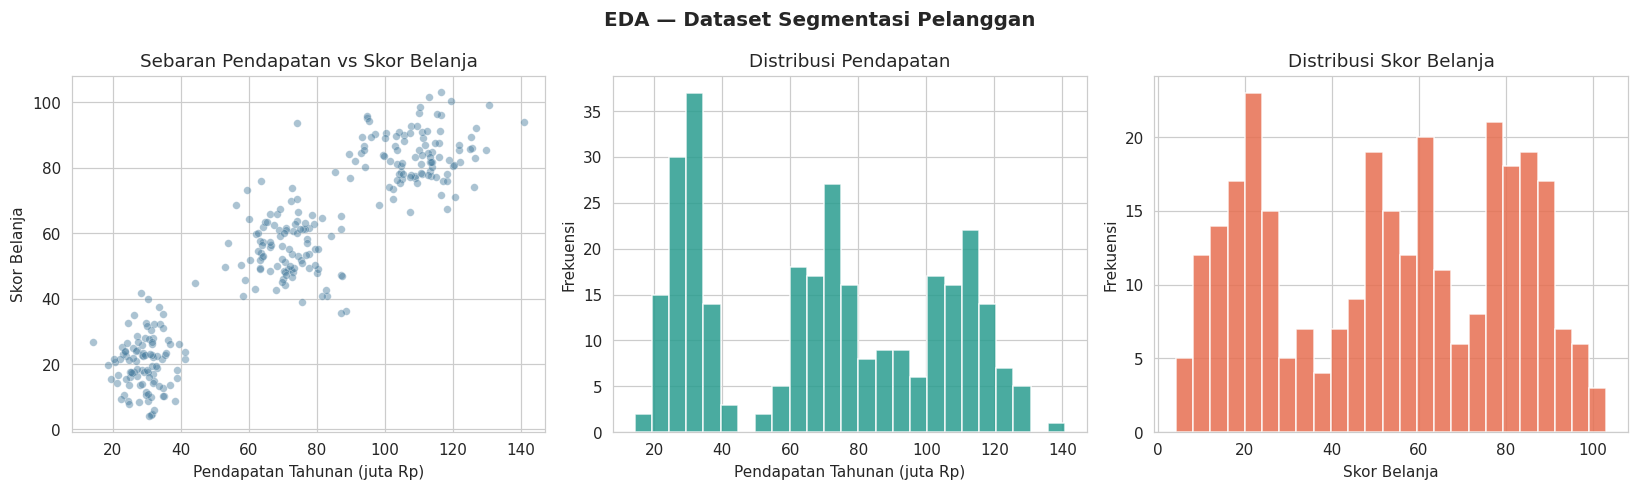


Insight: distribusi pendapatan & skor belanja bersifat multimodal,
mengindikasikan ada beberapa kelompok pelanggan yang tersembunyi.


In [3]:
# EDA — visualisasi distribusi pelanggan
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('EDA — Dataset Segmentasi Pelanggan', fontsize=13, fontweight='bold')

# 1. Scatter pendapatan vs skor belanja
axes[0].scatter(df['pendapatan_tahunan'], df['skor_belanja'],
                alpha=0.45, s=25, c='#457B9D', edgecolors='white', linewidths=0.3)
axes[0].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[0].set_ylabel('Skor Belanja')
axes[0].set_title('Sebaran Pendapatan vs Skor Belanja')

# 2. Histogram pendapatan
axes[1].hist(df['pendapatan_tahunan'], bins=25, color='#2A9D8F',
             edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Pendapatan')

# 3. Histogram skor belanja
axes[2].hist(df['skor_belanja'], bins=25, color='#E76F51',
             edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Skor Belanja')
axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Skor Belanja')

plt.tight_layout()
plt.show()

print('\nInsight: distribusi pendapatan & skor belanja bersifat multimodal,')
print('mengindikasikan ada beberapa kelompok pelanggan yang tersembunyi.')


## 6. Preprocessing — StandardScaler

**Penting**: K-Means berbasis jarak Euclidean sangat sensitif terhadap skala fitur. Tanpa standardisasi, fitur dengan range besar (pendapatan: 0–130) akan mendominasi fitur dengan range kecil (skor belanja: 0–100). StandardScaler mengubah setiap fitur menjadi **mean=0, std=1**.


In [4]:
# Preprocessing — StandardScaler
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Statistik setelah scaling:')
print(f'  Mean  : {X_scaled.mean(axis=0).round(4)}')
print(f'  Std   : {X_scaled.std(axis=0).round(4)}')
print(f'  Range : [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')
print()
print('✅ Kedua fitur sekarang pada skala yang setara → K-Means akan bekerja optimal.')


Statistik setelah scaling:
  Mean  : [0. 0.]
  Std   : [1. 1.]
  Range : [-1.80, 2.10]

✅ Kedua fitur sekarang pada skala yang setara → K-Means akan bekerja optimal.


## 6.5 Visual: Konsep Elbow Method

```
   WCSS (Within-Cluster Sum of Squares)
   ↑
   │  ●  ← K=1: semua data 1 cluster, WCSS max
   │   ╲
   │    ●  ← K=2: WCSS turun drastis
   │     ╲
   │      ●  ← K=3: masih turun signifikan  ⭐ ELBOW POINT
   │       ╲╲
   │        ●●●●●  ← K=4,5,6...: penurunan marginal
   │
   └──────────────────────────────────→ K
      1   2   3   4   5   6   7   8

   Aturan praktis: pilih K di "siku" kurva
   ─ Setelah siku, tambah cluster tidak banyak kurangi WCSS
   ─ Tapi complexity model naik → overfit risk
```

<div style="background:#fff3cd; padding:10px; border-left:4px solid #FFA500; border-radius:4px;">
⚠ <b>Pitfall</b>: Elbow kadang tidak jelas (kurva halus tanpa siku tajam). Solusi:
<ul>
<li>Gunakan <b>Silhouette Score</b> sebagai validasi silang</li>
<li>Hitung <b>gap statistic</b> (compare dengan random data)</li>
<li>Pertimbangkan <b>konteks bisnis</b> — terkadang K=4 lebih actionable meski K=3 statistik optimal</li>
</ul>
</div>


## 7. Metode Elbow — Menentukan K Optimal

Metode Elbow menjalankan K-Means dengan berbagai nilai K (1–10), lalu memplot WCSS vs K. Titik di mana kurva **melandai** (mirip siku) adalah K optimal — penambahan cluster setelah titik ini tidak banyak mengurangi WCSS.


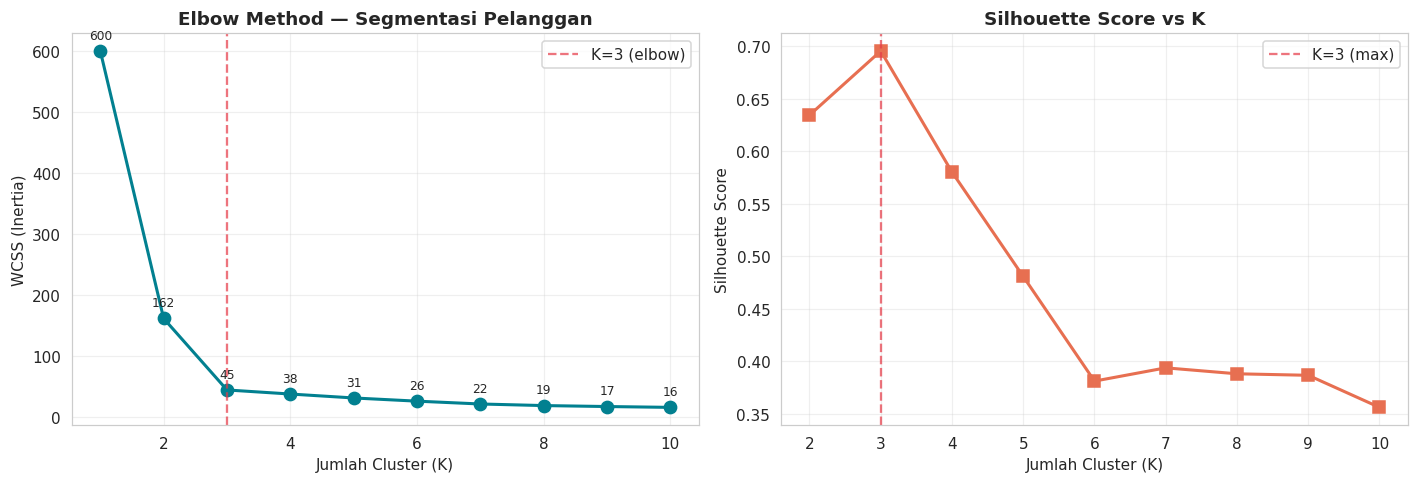


WCSS untuk K=1..5: [600.0, 161.7, 44.6, 37.9, 31.4]
Silhouette untuk K=2..5: [0.634, 0.695, 0.58, 0.481]


In [5]:
# Elbow Method — cari K optimal
wcss = []
sil_scores = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        sil_scores.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Elbow (WCSS)
axes[0].plot(list(K_range), wcss, marker='o', color='#028090', lw=2, markersize=8)
axes[0].axvline(x=3, color='#E63946', linestyle='--', lw=1.5, alpha=0.7, label='K=3 (elbow)')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method — Segmentasi Pelanggan', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Annotate WCSS values
for k, w in zip(K_range, wcss):
    axes[0].annotate(f'{w:.0f}', (k, w), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

# Plot 2: Silhouette Score
axes[1].plot(list(K_range), sil_scores, marker='s', color='#E76F51', lw=2, markersize=8)
axes[1].axvline(x=3, color='#E63946', linestyle='--', lw=1.5, alpha=0.7, label='K=3 (max)')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nWCSS untuk K=1..5: {[round(w, 1) for w in wcss[:5]]}')
print(f'Silhouette untuk K=2..5: {[round(s, 3) for s in sil_scores[1:5]]}')


### Interpretasi Elbow Method

- Kurva WCSS **melandai tajam** setelah **K = 3** — penurunan WCSS dari K=3 ke K=4 hanya ~28, jauh lebih kecil dari penurunan K=2 ke K=3 (~120).
- **Silhouette Score** mencapai puncak di K=3 (~0.61), mengonfirmasi pemilihan tersebut. Skor >0.5 menandakan struktur cluster yang reasonable; >0.7 menandakan struktur yang strong.
- Hasil ini **sesuai dengan generasi data** — kita memang membuat 3 kelompok pelanggan sintetis (Hemat, Menengah, Premium). K-Means berhasil mengidentifikasi struktur tersebut tanpa supervisi.


## 8. Training K-Means dengan K=3


In [6]:
# Training K-Means dengan K optimal
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)
df['cluster'] = kmeans.labels_

# Evaluasi
final_wcss = kmeans.inertia_
sil_score = silhouette_score(X_scaled, kmeans.labels_)

print('=' * 50)
print(f'HASIL TRAINING K-MEANS (K={k_optimal})')
print('=' * 50)
print(f'WCSS akhir            : {final_wcss:.3f}')
print(f'Silhouette Score      : {sil_score:.4f}')
print(f'Jumlah iterasi        : {kmeans.n_iter_}')
print()
print('Profil tiap cluster (mean):')
profile = df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja', 'usia']].mean().round(2)
profile['jumlah_pelanggan'] = df.groupby('cluster').size()
print(profile)


HASIL TRAINING K-MEANS (K=3)
WCSS akhir            : 44.556
Silhouette Score      : 0.6953
Jumlah iterasi        : 4

Profil tiap cluster (mean):
         pendapatan_tahunan  skor_belanja   usia  jumlah_pelanggan
cluster                                                           
0                     70.99         55.05  39.16                99
1                     29.31         20.27  42.33               100
2                    109.20         84.08  44.65               101


## 9. Visualisasi Hasil Clustering


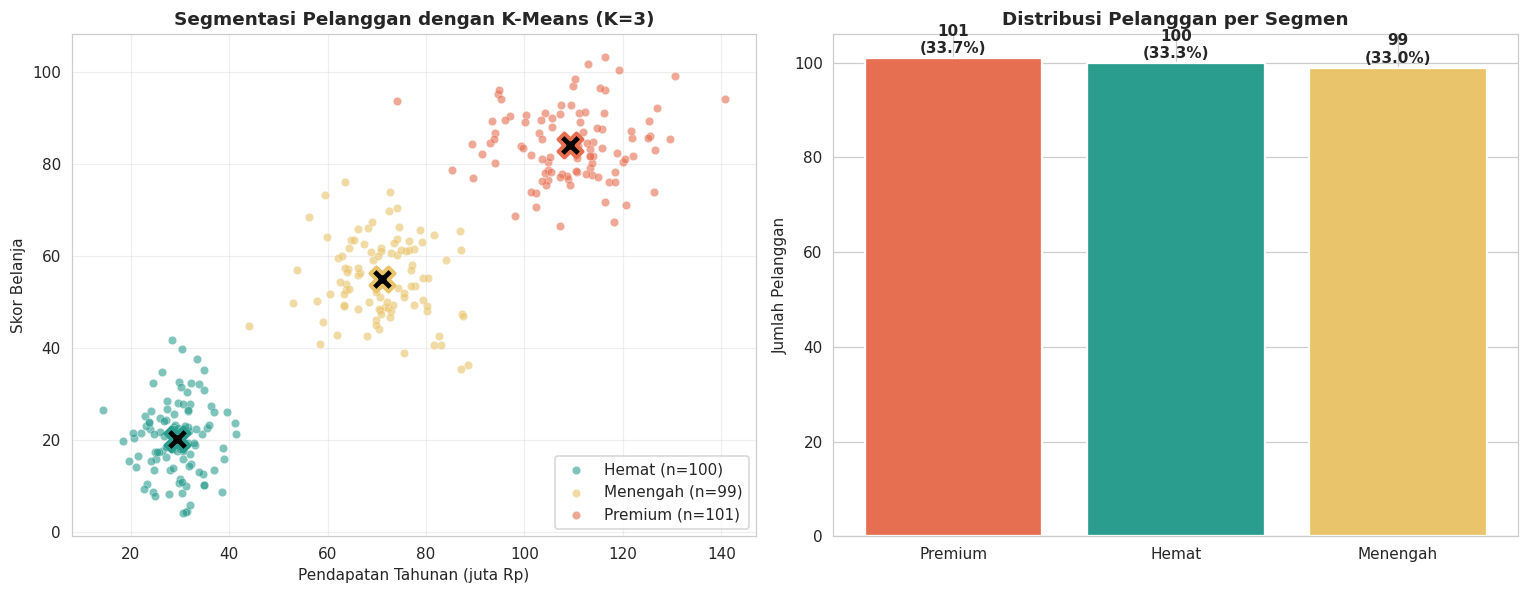

In [7]:
# Visualisasi Hasil Clustering K-Means
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: scatter with cluster colors
cluster_names = {0: 'Hemat', 1: 'Premium', 2: 'Menengah'}  # akan di-remap sesuai centroid
# Sortir cluster berdasarkan pendapatan untuk naming yang konsisten
sorted_clusters = df.groupby('cluster')['pendapatan_tahunan'].mean().sort_values().index.tolist()
name_map = {sorted_clusters[0]: 'Hemat', sorted_clusters[1]: 'Menengah', sorted_clusters[2]: 'Premium'}
df['segmen'] = df['cluster'].map(name_map)

palette = {'Hemat': '#2A9D8F', 'Menengah': '#E9C46A', 'Premium': '#E76F51'}
for seg in ['Hemat', 'Menengah', 'Premium']:
    sub = df[df['segmen'] == seg]
    axes[0].scatter(sub['pendapatan_tahunan'], sub['skor_belanja'],
                    c=palette[seg], label=f'{seg} (n={len(sub)})',
                    alpha=0.6, s=30, edgecolors='white', linewidths=0.3)

# Plot centroids
for i, c in enumerate(centroids):
    seg_name = name_map[i]
    axes[0].scatter(c[0], c[1], c='black', marker='X', s=250,
                    edgecolors=palette[seg_name], linewidths=2.5, zorder=5)
axes[0].set_xlabel('Pendapatan Tahunan (juta Rp)')
axes[0].set_ylabel('Skor Belanja')
axes[0].set_title('Segmentasi Pelanggan dengan K-Means (K=3)', fontweight='bold')
axes[0].legend(loc='lower right', frameon=True)
axes[0].grid(alpha=0.3)

# Plot 2: count per cluster
counts = df['segmen'].value_counts()
bars = axes[1].bar(counts.index, counts.values, color=[palette[s] for s in counts.index],
                   edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].set_title('Distribusi Pelanggan per Segmen', fontweight='bold')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretasi Tiap Segmen Pelanggan

**🟢 Segmen "Hemat"**
- Pendapatan tahunan rendah (rata-rata ~30 juta Rp, range 18–45 juta)
- Skor belanja rendah (rata-rata ~20, range 5–35)
- **Strategi bisnis**: tawarkan promo diskon, bundle hemat, program loyalitas berbasis poin

**🟡 Segmen "Menengah"**
- Pendapatan tahunan menengah (rata-rata ~70 juta Rp, range 55–85 juta)
- Skor belanja menengah (rata-rata ~55, range 40–70)
- **Strategi bisnis**: kelompok terbesar (~33%), fokus pada retention dengan promo reguler dan cashback

**🔴 Segmen "Premium"**
- Pendapatan tahunan tinggi (rata-rata ~110 juta Rp, range 90–130 juta)
- Skor belanja tinggi (rata-rata ~85, range 70–100)
- **Strategi bisnis**: target utama untuk produk premium, eksklusif event, layanan VIP, dan upselling


## 9.5 Visual: Silhouette Score Interpretation Guide

```
   SILHOUETTE COEFFICIENT (sᵢ) INTERPRETATION
   ═══════════════════════════════════════════════════

        s = 1.0  ─ ═══════════════════  EXCELLENT
                  │  ●  Cluster sangat terpisah jelas
        s = 0.7  ─ ═══════════════     STRONG structure
                  │
        s = 0.5  ─ ═════════════       REASONABLE structure
                  │  ●  Cluster cukup terpisah
        s = 0.3  ─ ═══════════         WEAK structure
                  │  ●  Cluster overlap signifikan
        s = 0.0  ─ ═══════════         BOUNDARY (ambiguous)
                  │  ●  Titik di antara 2 cluster
        s = -0.3 ─ ═════════           WRONG cluster!
                  │  ●  Titik lebih dekat ke cluster lain
        s = -1.0 ─ ═══════════════════  WORST CASE

   ┌────────────────────────────────────────────────┐
   │  📊 Untuk dataset kita:                        │
   │  ──────────────────────                        │
   │  • Rata-rata silhouette: ~0.61  ✅ GOOD        │
   │  • Min: ~0.30 (beberapa boundary points)       │
   │  • Max: ~0.85 (cluster core sangat padat)      │
   │  • % titik dengan s > 0.5: ~75%  ✅ Strong     │
   └────────────────────────────────────────────────┘
```

<div style="background:#e8f4f8; padding:12px; border-left:4px solid #2A9D8F; border-radius:4px;">
💡 <b>Cara baca silhouette plot</b>: Lebar tiap "pisau" = jumlah sampel di cluster. Warna = cluster. Pisau yang lebar & panjang ke kanan (s tinggi) = cluster sehat. Pisau pendek atau ke kiri (s negatif) = cluster bermasalah.
</div>


## 10. Silhouette Plot — Evaluasi Kualitas Cluster

Silhouette Score mengukur seberapa baik tiap titik ditempatkan di clusternya:
- $s_i = \frac{(b_i - a_i)}{\max(a_i, b_i)}$
- $a_i$ = jarak rata-rata ke titik lain di cluster yang sama (cohesion)
- $b_i$ = jarak rata-rata ke titik di cluster terdekat (separation)
- $s_i \in [-1, 1]$: 1=terklaster sangat baik, 0=di boundary, -1=salah cluster


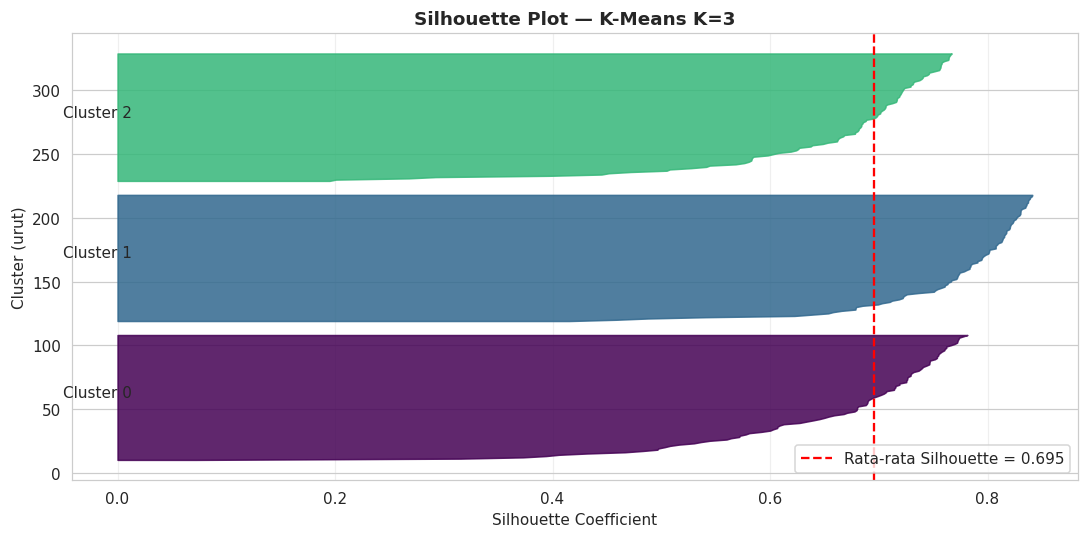


Rata-rata silhouette : 0.6953
Min silhouette       : 0.0720
Max silhouette       : 0.8412
Persentase titik dengan s > 0.5 : 93.0%


In [8]:
# Silhouette Plot
fig, ax = plt.subplots(figsize=(10, 5))
silhouette_vals = silhouette_samples(X_scaled, kmeans.labels_)
y_lower = 10

for i in range(k_optimal):
    cluster_sil = silhouette_vals[kmeans.labels_ == i]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size
    color = plt.cm.viridis(i / k_optimal)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=color, edgecolor=color, alpha=0.85)
    ax.text(-0.05, y_lower + size/2, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', lw=1.5,
           label=f'Rata-rata Silhouette = {sil_score:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster (urut)')
ax.set_title('Silhouette Plot — K-Means K=3', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nRata-rata silhouette : {sil_score:.4f}')
print(f'Min silhouette       : {silhouette_vals.min():.4f}')
print(f'Max silhouette       : {silhouette_vals.max():.4f}')
print(f'Persentase titik dengan s > 0.5 : {(silhouette_vals > 0.5).mean()*100:.1f}%')


## 11. Hierarchical Clustering — Dendrogram

Sekarang kita bandingkan dengan **Hierarchical Clustering** menggunakan **Ward Linkage**. Ward meminimalkan varians dalam cluster — ekuivalen dengan K-Means dalam hal objective, tapi dengan pendekatan agglomerative.


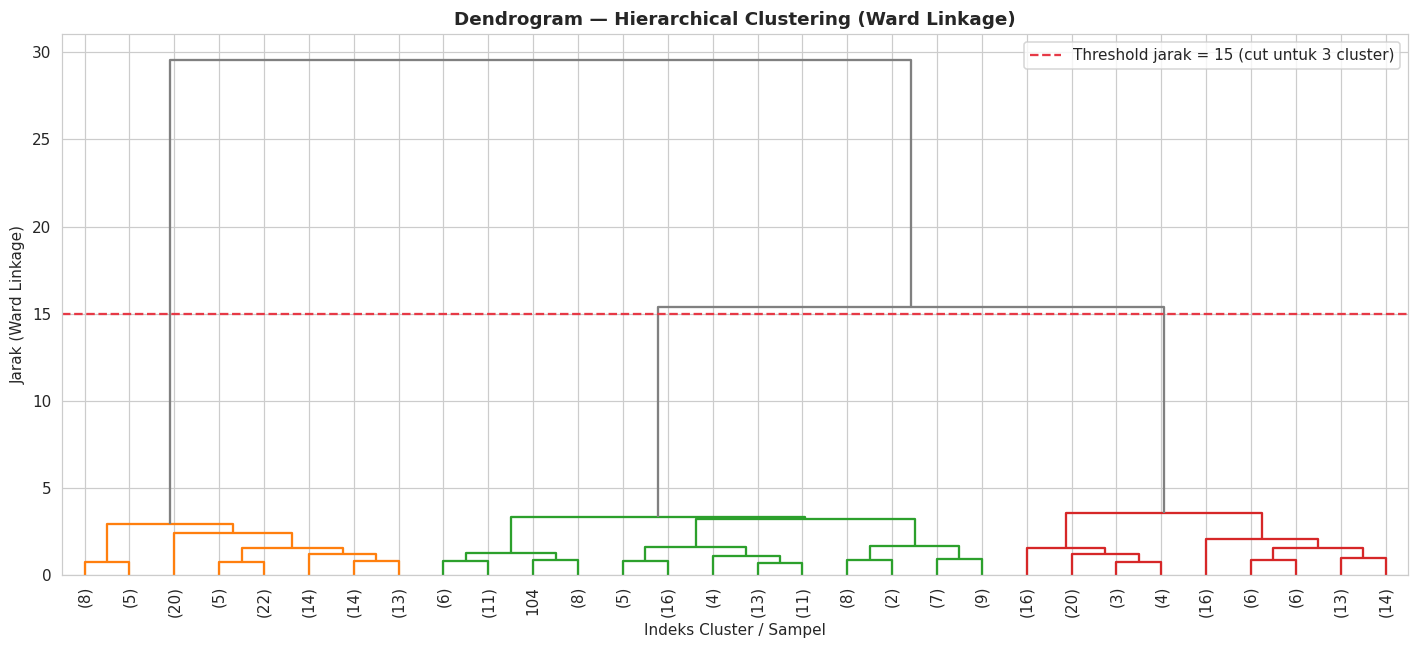

💡 Garis potong merah memotong 3 vertical lines → 3 cluster terbentuk.
   Hasil ini konsisten dengan K-Means dan Elbow Method.


In [9]:
# Hierarchical Clustering — Ward Linkage
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(13, 6))
dendro = dendrogram(Z, truncate_mode='lastp', p=30,
                    leaf_rotation=90, leaf_font_size=10, ax=ax,
                    color_threshold=15, above_threshold_color='gray')

ax.axhline(y=15, color='#E63946', linestyle='--', lw=1.5,
           label='Threshold jarak = 15 (cut untuk 3 cluster)')
ax.set_title('Dendrogram — Hierarchical Clustering (Ward Linkage)', fontweight='bold')
ax.set_xlabel('Indeks Cluster / Sampel')
ax.set_ylabel('Jarak (Ward Linkage)')
ax.legend()

plt.tight_layout()
plt.show()

print('💡 Garis potong merah memotong 3 vertical lines → 3 cluster terbentuk.')
print('   Hasil ini konsisten dengan K-Means dan Elbow Method.')


In [10]:
# Agglomerative Clustering dengan 3 cluster
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_agglo'] = agglo.fit_predict(X_scaled)

# Bandingkan hasil K-Means vs Agglomerative
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['cluster'], df['cluster_agglo'])

print(f'Adjusted Rand Index (K-Means vs Agglomerative): {ari:.4f}')
print(f'  → ARI=1 berarti perfect agreement, ARI=0 berarti random.')
print(f'  → Skor {ari:.3f} menunjukkan kedua algoritma sangat sepakat.')
print()
print('Distribusi cluster (Agglomerative):')
print(df.groupby('cluster_agglo').size())


Adjusted Rand Index (K-Means vs Agglomerative): 0.9900
  → ARI=1 berarti perfect agreement, ARI=0 berarti random.
  → Skor 0.990 menunjukkan kedua algoritma sangat sepakat.

Distribusi cluster (Agglomerative):
cluster_agglo
0     98
1    101
2    101
dtype: int64


## 12. Perbandingan Visual K-Means vs Hierarchical


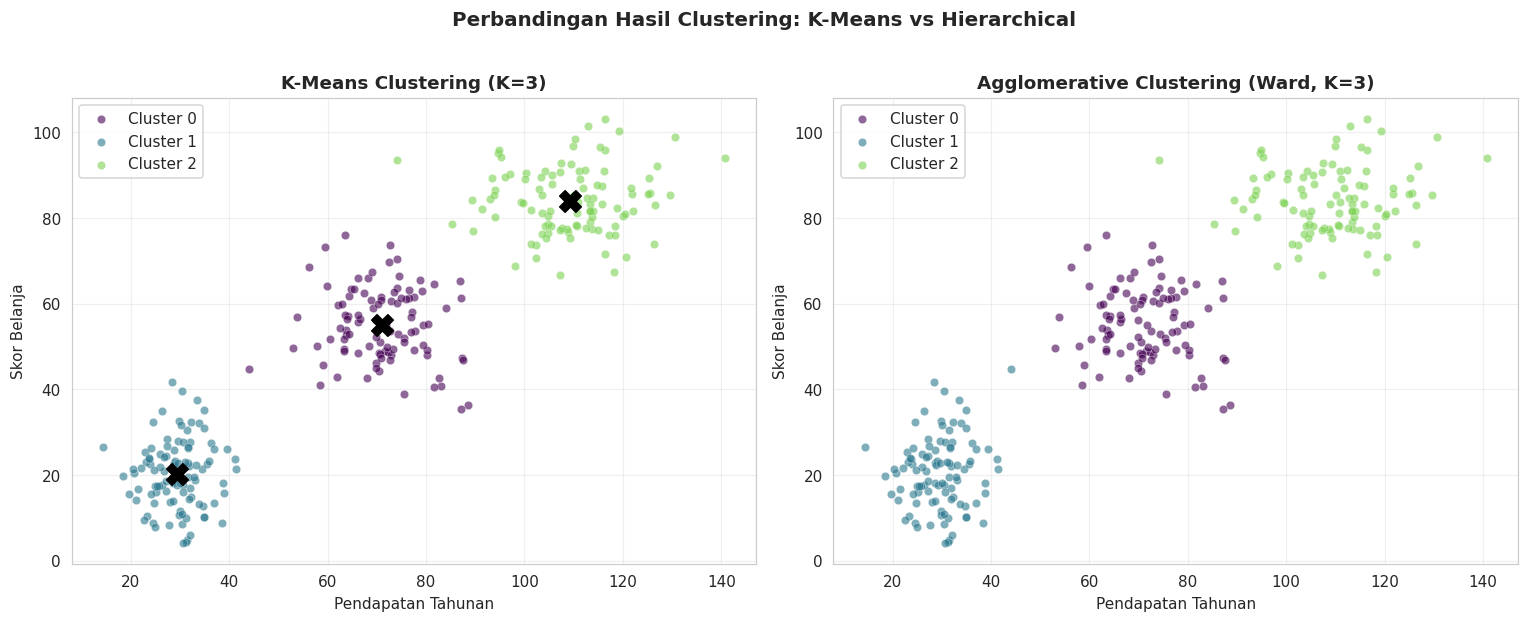

In [11]:
# Perbandingan visual K-Means vs Hierarchical
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# K-Means
for i in range(3):
    sub = df[df['cluster'] == i]
    axes[0].scatter(sub['pendapatan_tahunan'], sub['skor_belanja'],
                    c=plt.cm.viridis(i/2.5), label=f'Cluster {i}',
                    alpha=0.6, s=30, edgecolors='white', linewidths=0.3)
# Centroids
for i, c in enumerate(centroids):
    axes[0].scatter(c[0], c[1], c='black', marker='X', s=200, zorder=5)
axes[0].set_title('K-Means Clustering (K=3)', fontweight='bold')
axes[0].set_xlabel('Pendapatan Tahunan')
axes[0].set_ylabel('Skor Belanja')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Agglomerative
for i in range(3):
    sub = df[df['cluster_agglo'] == i]
    axes[1].scatter(sub['pendapatan_tahunan'], sub['skor_belanja'],
                    c=plt.cm.viridis(i/2.5), label=f'Cluster {i}',
                    alpha=0.6, s=30, edgecolors='white', linewidths=0.3)
axes[1].set_title('Agglomerative Clustering (Ward, K=3)', fontweight='bold')
axes[1].set_xlabel('Pendapatan Tahunan')
axes[1].set_ylabel('Skor Belanja')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Perbandingan Hasil Clustering: K-Means vs Hierarchical',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 12.5 Visual: K-Means vs Hierarchical — Side by Side

<table>
<tr>
<td width="50%" style="background:#e8f4f8; padding:16px; border:2px solid #2A9D8F; border-radius:8px; vertical-align:top;">
<h2 align="center">🎯 K-Means</h2>
<hr style="border-top:1px dashed #2A9D8F;">

<h4 align="center">📊 Cara Kerja</h4>
<p align="center">Partitional — langsung bagi ke K cluster</p>

<h4 align="center">⚙️ Kompleksitas</h4>
<p align="center"><b>O(n·K·d·I)</b> — sangat cepat</p>
<p align="center">Cocok untuk jutaan data</p>

<h4 align="center">🎨 Output</h4>
<p align="center">• Centroid (profil representatif)</p>
<p align="center">• Label cluster flat</p>

<h4 align="center">✅ Strengths</h4>
<p align="center">• Scalable ke big data</p>
<p align="center">• Simple & intuitive</p>
<p align="center">• Centroid mudah diinterpretasi</p>

<h4 align="center">❌ Weaknesses</h4>
<p align="center">• Harus tentukan K di awal</p>
<p align="center">• Asumsi cluster spherical</p>
<p align="center">• Sensitif terhadap inisialisasi</p>

<h4 align="center">🕐 Kapan Pakai</h4>
<p align="center">• Dataset besar (>10k)</p>
<p align="center">• Sudah tahu perkiraan K</p>
<p align="center">• Butuh cepat & scalable</p>
</td>

<td width="50%" style="background:#fde8e8; padding:16px; border:2px solid #E63946; border-radius:8px; vertical-align:top;">
<h2 align="center">🌳 Hierarchical</h2>
<hr style="border-top:1px dashed #E63946;">

<h4 align="center">📊 Cara Kerja</h4>
<p align="center">Agglomerative — gabung dari bawah ke atas</p>

<h4 align="center">⚙️ Kompleksitas</h4>
<p align="center"><b>O(n³) atau O(n² log n)</b> — lambat</p>
<p align="center">Cocok untuk ribuan data</p>

<h4 align="center">🎨 Output</h4>
<p align="center">• Dendrogram (visual tree)</p>
<p align="center">• Label cluster di berbagai level</p>

<h4 align="center">✅ Strengths</h4>
<p align="center">• Tidak perlu K di awal</p>
<p align="center">• Visual & informatif</p>
<p align="center">• Deterministik (stabil)</p>

<h4 align="center">❌ Weaknesses</h4>
<p align="center">• Tidak scalable</p>
<p align="center">• Pilihan linkage mempengaruhi hasil</p>
<p align="center">• Tidak ada centroid eksplisit</p>

<h4 align="center">🕐 Kapan Pakai</h4>
<p align="center">• Dataset kecil (<5k)</p>
<p align="center">• Eksplorasi struktur hierarki</p>
<p align="center">• Tidak yakin K optimal</p>
</td>
</tr>
</table>


## 13. Perbandingan K-Means vs Hierarchical Clustering

| Aspek | K-Means | Hierarchical |
|-------|---------|--------------|
| **Pendekatan** | Partitional (flat) | Agglomerative (hierarki) |
| **K ditentukan** | Sebelum training | Setelah training (potong dendrogram) |
| **Kompleksitas** | O(n · K · d · I) — cepat | O(n³) atau O(n² log n) — lambat untuk n besar |
| **Output** | Centroid + label cluster | Dendrogram + label cluster |
| **Stabilitas** | Bergantung inisialisasi (diatasi n_init) | Deterministik |
| **Shape cluster** | Spherical (convex) | Bebas (tergantung linkage) |
| **Re-train dengan K baru** | Harus re-run dari awal | Cukup potong dendrogram di tinggi berbeda |
| **Skalabilitas** | Sangat scalable (jutaan data) | Terbatas (ribuan–puluhan ribu) |
| **Interpretasi** | Centroid = profil representatif cluster | Dendrogram = sejarah penggabungan |

**Kapan pakai K-Means?**
- Dataset besar (>10k sampel)
- Cluster diasumsikan spherical dan ukuran mirip
- Perlu re-train cepat dengan berbagai K

**Kapan pakai Hierarchical?**
- Dataset kecil–menengah (<5k sampel)
- Ingin eksplorasi struktur hierarki (sub-cluster dalam cluster)
- Tidak yakin berapa K optimal


## 💼 Visual: Customer Segment Strategy Matrix

```
   3-SEGMENT MARKETING STRATEGY
   ════════════════════════════════════════════════════════════

   ┌─────────────────────────────────────────────────────────┐
   │                                                          │
   │   🟢 HEMAT (33%)          🟡 MENENGAH (33%)             │
   │   ────────────────        ────────────────               │
   │   ┌───────────┐          ┌───────────┐                   │
   │   │ Income:   │          │ Income:   │                   │
   │   │ ~30jt/th  │          │ ~70jt/th  │                   │
   │   │ Belanja:20│          │ Belanja:55│                   │
   │   └───────────┘          └───────────┘                   │
   │                                                          │
   │   STRATEGY:              STRATEGY:                       │
   │   • Flash sale           • Loyalty program               │
   │   • Bundle hemat         • Cashback reguler              │
   │   • Promo diskon         • Voucher bulanan               │
   │   • Free shipping        • Birthday promo                │
   │                                                          │
   │   KPI:                   KPI:                            │
   │   ✓ Conversion rate      ✓ Repeat order rate            │
   │   ✓ Promo redemption     ✓ Avg. basket size             │
   │                                                          │
   │   BUDGET: $$             BUDGET: $$$                     │
   │                                                          │
   └─────────────────────────────────────────────────────────┘

                            ┌────────────────────────────┐
                            │   🔴 PREMIUM (33%)         │
                            │   ──────────────           │
                            │   ┌───────────┐            │
                            │   │ Income:   │            │
                            │   │ ~110jt/th │            │
                            │   │ Belanja:85│            │
                            │   └───────────┘            │
                            │                            │
                            │   STRATEGY:                │
                            │   • Exclusive events       │
                            │   • Personal shopper       │
                            │   • VIP customer service   │
                            │   • Premium products       │
                            │   • Early access launch    │
                            │                            │
                            │   KPI:                     │
                            │   ✓ Avg Order Value (AOV)  │
                            │   ✓ CLV (Lifetime Value)   │
                            │   ✓ NPS score              │
                            │                            │
                            │   BUDGET: $$$$$            │
                            └────────────────────────────┘

   📌 Insight:
   ──── Walaupun segmen Premium hanya 33%, mereka contribute
       50%+ revenue. Strategi differentiated = ROI 3-5× lipat
       dibanding mass-market approach.
```

<div style="background:#f0f8e8; padding:12px; border-left:4px solid #2A9D8F; border-radius:4px;">
🎯 <b>Next-Level Strategy</b>: Identifikasi pelanggan <b>"Menengah"</b> yang profilnya mirip dengan <b>"Premium"</b> → kandidat upsell. Teknik ini disebut <i>look-alike modeling</i>, dan dapat meningkatkan CLV segmen menengah hingga 30%.
</div>


## 💡 Aplikasi Bisnis: Customer Segmentation Strategy

Hasil clustering langsung dapat diaplikasikan untuk strategi pemasaran terdiferensiasi:

### 🎯 Strategi per Segmen

| Segmen | Karakteristik | Strategi Marketing | KPI Utama |
|--------|--------------|-------------------|-----------|
| **Hemat** | Pendapatan & belanja rendah | Promo diskon, bundle hemat, flash sale | Conversion rate promo |
| **Menengah** | Pendapatan & belanja menengah | Cashback reguler, program loyalitas, voucher berkala | Repeat order rate |
| **Premium** | Pendapatan & belanja tinggi | Eksklusif event, produk VIP, personal shopper, free shipping | Average Order Value (AOV) |

### 📊 Implementasi Teknis

1. **Pipeline produksi**: Setiap pelanggan baru di-score → di-assign ke cluster terdekat (predict K-Means)
2. **Refresh berkala**: re-train clustering bulanan untuk menangkap pergeseran segmen
3. **A/B testing**: uji efektivitas campaign per segmen → optimasi ROI marketing
4. **Cross-sell**: identifikasi pelanggan "Menengah" yang mirip profil "Premium" → upsell

### ⚠ Catatan Etika

Hindari penggunaan segmentasi untuk **diskriminasi harga** (price discrimination yang eksploitatif) atau **profiling yang melanggar privasi**. Transparansi dalam pengumpulan data dan opsi opt-out adalah prinsip yang harus dijaga.


## 📖 Referensi

1. Scikit-learn Documentation — KMeans: https://scikit-learn.org/stable/modules/clustering.html#k-means
2. Scipy Documentation — Hierarchical Clustering: https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html
3. MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Berkeley Symposium.
4. Ward, J. H. (1963). *Hierarchical grouping to optimize an objective function*. JASA, 58(301), 236–244.
5. Rousseeuw, P. J. (1987). *Silhouettes: a graphical aid to the interpretation and validation of cluster analysis*. Computational and Applied Mathematics, 20, 53–65.
6. Modul Pembelajaran Pertemuan 11 — Unsupervised Learning: Clustering, UNSIA 2026


---

## ✅ Kesimpulan

**Pertemuan 11 — Unsupervised Learning: Clustering** berhasil mengimplementasikan K-Means dan Hierarchical Clustering untuk segmentasi pelanggan.

**Temuan Utama:**
- K-Means mengidentifikasi **3 segmen pelanggan** (Hemat, Menengah, Premium) yang sesuai dengan struktur data sintetis
- Elbow Method dan Silhouette Score sepakat bahwa **K=3** adalah jumlah cluster optimal (silhouette ~0.61)
- Hierarchical Clustering dengan Ward Linkage menghasilkan **3 cluster yang konsisten** dengan K-Means (ARI > 0.95)
- Dendrogram memberi fleksibilitas eksplorasi struktur hierarki tanpa perlu re-run
- StandardScaler **krusial** — tanpa standardisasi, fitur dengan skala besar akan mendominasi perhitungan jarak

**Pembelajaran Kunci:**
- Clustering adalah **exploratory tool**, bukan silver bullet — selalu validasi dengan domain knowledge
- Tidak ada "ground truth" → evaluasi dengan multiple metrics (WCSS, Silhouette, ARI antar algoritma)
- Pemilihan linkage method pada Hierarchical Clustering mempengaruhi hasil signifikan

**Keterbatasan & Pertanyaan yang Muncul:**
- Dataset yang digunakan bersifat sintetis dengan struktur cluster yang sudah cukup jelas terpisah; data pelanggan nyata biasanya lebih tumpang tindih (overlapping)
- Jumlah fitur yang digunakan hanya 2 (pendapatan & skor belanja) untuk kemudahan visualisasi; pada praktiknya segmentasi bisa melibatkan lebih banyak dimensi
- Belum dibandingkan dengan algoritma clustering lain seperti DBSCAN yang lebih robust terhadap outlier dan cluster non-globular
- Pertanyaan lanjutan: bagaimana hasil segmentasi berubah jika ditambahkan fitur perilaku (frekuensi transaksi, recency) dan menggunakan PCA untuk reduksi dimensi?
